# Arabic Fake News Detection — Literature-Style Baseline

**Purpose:** Reproduce a standard, unoptimised baseline that mirrors what a typical Arabic fake news paper would report *before* proposing any improvements.  
All design choices (preprocessing, models, hyperparameters) are intentionally kept at their simplest so that this notebook can serve as an honest lower-bound reference for a more advanced, data-centric methodology.

---

**Datasets**

| Dataset | Train / Eval role | Text column | Label column |
|---------|------------------|-----------|--------------|
| VERA | Training | `text_arabic` | `label` |
| AraFacts | Training (binary-mapped) | `claim` | `source_label` |
| Saheeh EARLY | Training | `text` | `binary_label` |
| Saheeh LATE | **Zero-shot evaluation only** | `text` | `binary_label` |

> ⚠️ Saheeh LATE is **never** used for training.

**Models trained**
1. TF-IDF + Logistic Regression
2. AraBERT v2 (`aubmindlab/bert-base-arabertv2`)
3. MARBERTv2 (`UBC-NLP/MARBERTv2`)


## 0 · Environment & Imports

In [1]:
# ── install dependencies (run once) ─────────────────────────────────────────
import subprocess, sys

pkgs = [
    "transformers>=4.38",
    "datasets",
    "torch",
    "scikit-learn>=1.3",
    "pandas",
    "openpyxl",        # read .xlsx
    "seaborn",
    "matplotlib",
    "tqdm",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

0

In [2]:
import re, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


---
## 1 · Load Raw Data

In [3]:
# ── file paths ───────────────────────────────────────────────────────────────
VERA_PATH         = "VERAARAB_dataset.xlsx"
ARAFACTS_PATH     = "AraFacts.csv"
SAHEEH_EARLY_PATH = "saheeh_temporal_early.csv"
SAHEEH_LATE_PATH  = "saheeh_temporal_late.csv"

# ── load ─────────────────────────────────────────────────────────────────────
vera_raw         = pd.read_excel(VERA_PATH)
arafacts_raw     = pd.read_csv(ARAFACTS_PATH,     low_memory=False)
saheeh_early_raw = pd.read_csv(SAHEEH_EARLY_PATH, low_memory=False)
saheeh_late_raw  = pd.read_csv(SAHEEH_LATE_PATH,  low_memory=False)

# ── sanity-check Saheeh columns ──────────────────────────────────────────────
for d in (saheeh_early_raw, saheeh_late_raw):
    assert {"text", "binary_label"}.issubset(d.columns)

print("VERA         :", vera_raw.shape,         "| columns:", vera_raw.columns.tolist())
print("AraFacts     :", arafacts_raw.shape,     "| columns:", arafacts_raw.columns.tolist())
print("Saheeh EARLY :", saheeh_early_raw.shape)
print("Saheeh LATE  :", saheeh_late_raw.shape)

VERA         : (20084, 78) | columns: ['tweet_id', 'possibly_sensitive', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'bookmark_count', 'impression_count', 'user_id', 'lang', 'annotations_text', 'annotations_type', 'hashtags', 'mentions', 'urls', 'urls_titles', 'urls_desc', 'context_domain', 'context_domain_desc', 'context_entity', 'context_entity_desc', 'copyright', 'withheld_country_codes', 'created_at', 'is_edit_eligible', 'text', 'reply_settings', 'label', 'user_created_at', 'user_description', 'user_description_urls', 'user_description_hashtags', 'user_description_mentions', 'location', 'protected', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'user_like_count', 'verified', 'claim_id', 'text_arabic', 'text_length', 'emojis', 'emojis_count', 'emojis_total_count', 'annotations_count', 'organizations', 'organizations_count', 'persons', 'persons_count', 'places', 'places_count', 'products', 'products_count', 'hashtags_count', 'mentions_count', '

In [4]:
# ── quick peek at label distributions ────────────────────────────────────────
print("=== VERA label distribution ===")
print(vera_raw["label"].value_counts(), "\n")

print("=== AraFacts source_label distribution ===")
print(arafacts_raw["source_label"].value_counts(), "\n")

print("=== Saheeh EARLY binary_label distribution ===")
print(saheeh_early_raw["binary_label"].value_counts(), "\n")

print("=== Saheeh LATE binary_label distribution ===")
print(saheeh_late_raw["binary_label"].value_counts())

=== VERA label distribution ===
label
1    11076
0     9008
Name: count, dtype: int64 

=== AraFacts source_label distribution ===
source_label
مضلل                    1481
زائف                    1031
خطأ                      882
fake                     749
misleading-title         420
partially-fake           160
 مضلل                    122
صحيح                      85
correct                   70
إثارة                     63
مركب                      62
 زائف                     61
misleading                53
ساخر                      52
غير صحيح                  44
sarcastic                 35
انتقائي                   30
مشكوك فيه                 26
صحيح جزئياً               23
خرافة                     19
missing-content            8
opinion                    6
مجتزأ                      6
 إثارة                     6
 صحيح                      4
مركّبة                     3
 ساخر                      3
 انتقائي                   2
مركّب                      2
deceptive      

---
## 2 · Basic Preprocessing

Exactly four operations — no more:
1. Unicode normalization (NFC)
2. Remove URLs
3. Collapse multiple spaces
4. Strip leading / trailing spaces

In [5]:
def basic_preprocess(text: str) -> str:
    """Minimal, literature-standard preprocessing for Arabic text."""
    if not isinstance(text, str):
        return ""
    # 1. Unicode normalisation
    text = unicodedata.normalize("NFC", text)
    # 2. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # 3. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)
    # 4. Strip leading / trailing spaces
    text = text.strip()
    return text

---
## 3 · Dataset Construction

### 3.1 — Standardise each source to `(text, label)` with binary labels

In [6]:
# ── VERA ─────────────────────────────────────────────────────────────────────
# 'label' is assumed to already be binary (0 / 1).  Apply preprocessing.
vera = pd.DataFrame({
    "text":  vera_raw["text_arabic"].apply(basic_preprocess),
    "label": vera_raw["label"].astype(int),
})
print(f"VERA ready: {len(vera):,} rows | label counts:\n{vera['label'].value_counts()}\n")

VERA ready: 20,084 rows | label counts:
label
1    11076
0     9008
Name: count, dtype: int64



In [7]:
# ── AraFacts ─────────────────────────────────────────────────────────────────
# source_label → binary:
#   'true' / 'mostly-true' / 'half-true'  → 1  (credible)
#   everything else                        → 0  (not credible)

CREDIBLE_LABELS = {"true", "mostly-true", "half-true"}

def map_arafacts(label):
    if isinstance(label, str) and label.strip().lower() in CREDIBLE_LABELS:
        return 1
    return 0

arafacts = pd.DataFrame({
    "text":  arafacts_raw["claim"].apply(basic_preprocess),
    "label": arafacts_raw["source_label"].apply(map_arafacts),
})
print(f"AraFacts ready: {len(arafacts):,} rows | label counts:\n{arafacts['label'].value_counts()}\n")

AraFacts ready: 6,222 rows | label counts:
label
0    6222
Name: count, dtype: int64



In [8]:
# ── Saheeh EARLY (training only) ─────────────────────────────────────────────
saheeh_early = pd.DataFrame({
    "text":  saheeh_early_raw["text"].apply(basic_preprocess),
    "label": saheeh_early_raw["binary_label"].astype(int),
})
print(f"Saheeh EARLY ready: {len(saheeh_early):,} rows | label counts:\n{saheeh_early['label'].value_counts()}\n")

# ── Saheeh LATE (evaluation only — never touched during training) ─────────────
saheeh_late = pd.DataFrame({
    "text":  saheeh_late_raw["text"].apply(basic_preprocess),
    "label": saheeh_late_raw["binary_label"].astype(int),
})
print(f"Saheeh LATE  ready: {len(saheeh_late):,} rows | label counts:\n{saheeh_late['label'].value_counts()}")

Saheeh EARLY ready: 1,557 rows | label counts:
label
1    1135
0     422
Name: count, dtype: int64

Saheeh LATE  ready: 668 rows | label counts:
label
1    357
0    311
Name: count, dtype: int64


### 3.2 — Concatenate training sources & drop duplicates

In [9]:
train_full = pd.concat([vera, arafacts, saheeh_early], ignore_index=True)

before = len(train_full)
train_full = train_full.drop_duplicates(subset=["text"]).reset_index(drop=True)
after  = len(train_full)

print(f"Combined training set: {before:,} → {after:,} rows after removing {before - after:,} duplicates")
print(f"Label distribution:\n{train_full['label'].value_counts()}")

Combined training set: 27,863 → 24,366 rows after removing 3,497 duplicates
Label distribution:
label
0    14162
1    10204
Name: count, dtype: int64


### 3.3 — Train / Validation split (stratified, 8 % validation)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    train_full["text"].values,
    train_full["label"].values,
    test_size=0.08,
    random_state=SEED,
    stratify=train_full["label"].values,
)

# Evaluation set (zero-shot)
X_test = saheeh_late["text"].values
y_test = saheeh_late["label"].values

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}  (Saheeh LATE — zero-shot)")

Train : 22,416
Val   : 1,950
Test  : 668  (Saheeh LATE — zero-shot)


---
## 4 · Model 1 — TF-IDF + Logistic Regression

In [11]:
# ── TF-IDF vectoriser ─────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    analyzer="char_wb",   # character n-grams work well for Arabic
    ngram_range=(2, 5),
    max_features=100_000,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)

TF-IDF feature matrix shape (train): (22416, 100000)


In [12]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    C=1.0,
    solver="lbfgs",
    multi_class="auto",
)
lr.fit(X_train_tfidf, y_train)

# Validation performance (informational)
y_val_pred_lr = lr.predict(X_val_tfidf)
print("── Validation (TF-IDF + LR) ──")
print(classification_report(y_val, y_val_pred_lr, digits=4))

── Validation (TF-IDF + LR) ──
              precision    recall  f1-score   support

           0     0.8662    0.9029    0.8842      1133
           1     0.8570    0.8066    0.8310       817

    accuracy                         0.8626      1950
   macro avg     0.8616    0.8548    0.8576      1950
weighted avg     0.8623    0.8626    0.8619      1950



In [13]:
# ── Test performance ──────────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_tfidf)
print("── Test / Saheeh LATE (TF-IDF + LR) ──")
print(classification_report(y_test, y_pred_lr, digits=4))

── Test / Saheeh LATE (TF-IDF + LR) ──
              precision    recall  f1-score   support

           0     0.6900    0.8875    0.7764       311
           1     0.8694    0.6527    0.7456       357

    accuracy                         0.7620       668
   macro avg     0.7797    0.7701    0.7610       668
weighted avg     0.7859    0.7620    0.7599       668



---
## 5 · Transformer Models — Shared Infrastructure

In [14]:
# ── Shared hyperparameters (identical for both transformers) ──────────────────
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 1
LR_BERT    = 2e-5
WARMUP_RATIO = 0.1

In [15]:
class ArabicFakeNewsDataset(Dataset):
    """PyTorch dataset wrapping tokenised Arabic text."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [16]:
def train_transformer(model_name: str) -> AutoModelForSequenceClassification:
    """Fine-tune a pre-trained Arabic BERT model with fixed hyperparameters."""
    print(f"\n{'='*60}")
    print(f" Training: {model_name}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    ).to(DEVICE)

    # ── dataloaders ───────────────────────────────────────────────────────────
    train_ds = ArabicFakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = ArabicFakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = ArabicFakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    # ── optimiser & scheduler ─────────────────────────────────────────────────
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_BERT, eps=1e-8)
    total_steps   = len(train_loader) * EPOCHS
    warmup_steps  = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    # ── training loop ─────────────────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # Validation F1 per epoch
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(
                    input_ids      = batch["input_ids"].to(DEVICE),
                    attention_mask = batch["attention_mask"].to(DEVICE),
                )
                val_preds.extend(out.logits.argmax(dim=-1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="macro")
        print(f"  Epoch {epoch} | loss={avg_loss:.4f} | val macro-F1={val_f1:.4f}")

    # ── final test evaluation ─────────────────────────────────────────────────
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating on Saheeh LATE", leave=False):
            out = model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
            )
            test_preds.extend(out.logits.argmax(dim=-1).cpu().numpy())

    return model_name, np.array(test_preds)


def evaluate_and_report(model_label: str, y_true, y_pred):
    """Print metrics and plot confusion matrix for a given model."""
    print(f"\n{'='*60}")
    print(f" Results on Saheeh LATE — {model_label}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Macro F1  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print()
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Real", "Real"],
                yticklabels=["Not Real", "Real"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {model_label}")
    plt.tight_layout()
    plt.show()

---
## 6 · Evaluate Model 1 on Saheeh LATE


 Results on Saheeh LATE — TF-IDF + Logistic Regression
  Accuracy  : 0.7620
  Precision : 0.7797
  Recall    : 0.7701
  Macro F1  : 0.7610

              precision    recall  f1-score   support

           0     0.6900    0.8875    0.7764       311
           1     0.8694    0.6527    0.7456       357

    accuracy                         0.7620       668
   macro avg     0.7797    0.7701    0.7610       668
weighted avg     0.7859    0.7620    0.7599       668



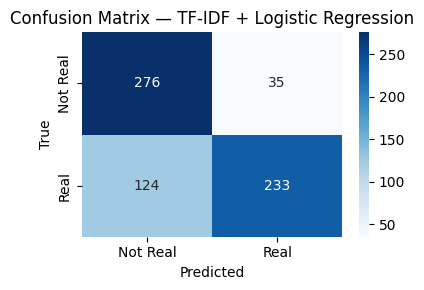

In [17]:
evaluate_and_report("TF-IDF + Logistic Regression", y_test, y_pred_lr)

---
## 7 · Model 2 — AraBERT v2

In [18]:
ARABERT_NAME = "aubmindlab/bert-base-arabertv2"
_, y_pred_arabert = train_transformer(ARABERT_NAME)


 Training: aubmindlab/bert-base-arabertv2


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/720k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

...

Epoch 2/3:   0%|          | 0/1401 [00:00<?, ?it/s]

  Epoch 2 | loss=0.2565 | val macro-F1=0.8859


Epoch 3/3:   0%|          | 0/1401 [00:00<?, ?it/s]

  Epoch 3 | loss=0.1529 | val macro-F1=0.8973


Evaluating on Saheeh LATE:   0%|          | 0/42 [00:00<?, ?it/s]

In [19]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
1
Tesla T4



 Results on Saheeh LATE — AraBERT v2
  Accuracy  : 0.8428
  Precision : 0.8453
  Recall    : 0.8461
  Macro F1  : 0.8428

              precision    recall  f1-score   support

           0     0.7943    0.8939    0.8411       311
           1     0.8962    0.7983    0.8444       357

    accuracy                         0.8428       668
   macro avg     0.8453    0.8461    0.8428       668
weighted avg     0.8488    0.8428    0.8429       668



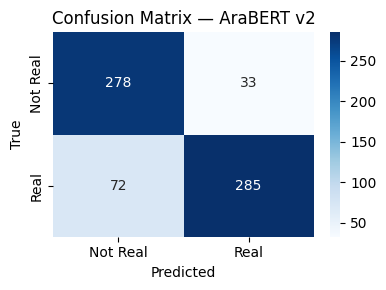

In [20]:
evaluate_and_report("AraBERT v2", y_test, y_pred_arabert)

---
## 8 · Model 3 — MARBERTv2

In [21]:
MARBERT_NAME = "UBC-NLP/MARBERTv2"
_, y_pred_marbert = train_transformer(MARBERT_NAME)


 Training: UBC-NLP/MARBERTv2


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch 2/3:   0%|          | 0/1401 [00:00<?, ?it/s]

  Epoch 2 | loss=0.2036 | val macro-F1=0.9104


Epoch 3/3:   0%|          | 0/1401 [00:00<?, ?it/s]

  Epoch 3 | loss=0.1081 | val macro-F1=0.9080


Evaluating on Saheeh LATE:   0%|          | 0/42 [00:00<?, ?it/s]


 Results on Saheeh LATE — MARBERTv2
  Accuracy  : 0.8518
  Precision : 0.8513
  Recall    : 0.8529
  Macro F1  : 0.8515

              precision    recall  f1-score   support

           0     0.8232    0.8682    0.8451       311
           1     0.8794    0.8375    0.8580       357

    accuracy                         0.8518       668
   macro avg     0.8513    0.8529    0.8515       668
weighted avg     0.8532    0.8518    0.8520       668



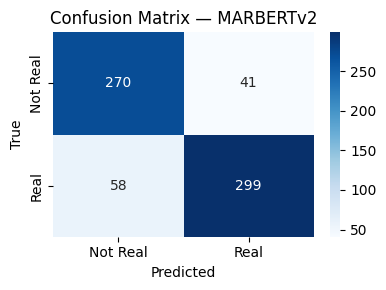

In [22]:
evaluate_and_report("MARBERTv2", y_test, y_pred_marbert)

---
## 9 · Summary Table

In [23]:
def summary_row(name, y_true, y_pred):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro F1" : round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
    }

summary = pd.DataFrame([
    summary_row("TF-IDF + LR",  y_test, y_pred_lr),
    summary_row("AraBERT v2",   y_test, y_pred_arabert),
    summary_row("MARBERTv2",    y_test, y_pred_marbert),
])

print("\n── Baseline results on Saheeh LATE (zero-shot) ──")
display(summary.set_index("Model"))


── Baseline results on Saheeh LATE (zero-shot) ──


,Accuracy,Precision,Recall,Macro F1
Model,,,,
TF-IDF + LR,0.7620,0.7797,0.7701,0.7610
AraBERT v2,0.8428,0.8453,0.8461,0.8428
MARBERTv2,0.8518,0.8513,0.8529,0.8515


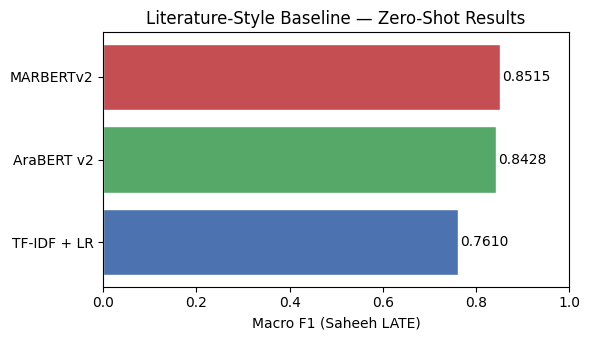

In [24]:
# ── Bar chart of Macro F1 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(
    summary["Model"],
    summary["Macro F1"],
    color=["#4C72B0", "#55A868", "#C44E52"],
    edgecolor="white",
)
for bar, val in zip(bars, summary["Macro F1"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=10)
ax.set_xlim(0, 1)
ax.set_xlabel("Macro F1 (Saheeh LATE)")
ax.set_title("Literature-Style Baseline — Zero-Shot Results")
plt.tight_layout()
plt.show()

---
## 10 · Discussion

The three models above constitute the **literature-style baseline** for the Arabic fake news detection task.

Key characteristics of this baseline:

* **Preprocessing** — only the four canonical steps (Unicode normalisation, URL removal, whitespace collapsing, stripping); no dialect normalisation, no diacritics removal, no stop-word filtering.
* **Training data** — raw concatenation of VERA, AraFacts (binary-mapped), and Saheeh EARLY; only exact duplicates removed.
* **No class rebalancing, no threshold tuning, no domain adaptation, no feature engineering.**
* **Evaluation** — zero-shot transfer to Saheeh LATE, which was never seen during training.

These results serve as the reference point against which any data-centric improvement (better label mapping, domain-aware sampling, temporal de-biasing, etc.) should be compared.
